## 1. Project Overview

### Product Analytics & User Growth — SaaS / Tech

### Business Context :
This project analyzes a SaaS product to understand how users are acquired,
how they interact with the product, how they convert into paying customers,
how revenue grows, and which factors are associated with customer churn.

### Business Problem :
The company wants to answer key business questions related to:
- User acquisition and growth
- Product engagement and feature adoption
- User conversion and funnel performance
- Customer retention and churn
- Subscription and revenue performance
- Marketing effectiveness
- Customer support experience

### Project Objectives :

1. Measure user growth and acquisition performance.
2. Understand user engagement and product usage patterns.
3. Identify important product features and user behaviors.
4. Analyze conversion and retention across user cohorts.
5. Evaluate subscription and revenue performance.
6. Compare marketing channels and campaign performance.
7. Identify patterns associated with customer churn.

### 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

### 3. Load Datasets

In [3]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "raw"

users = pd.read_csv(DATA_DIR / "users.csv")
sessions = pd.read_csv(DATA_DIR / "sessions.csv")
subscriptions = pd.read_csv(DATA_DIR / "subscriptions.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
marketing = pd.read_csv(DATA_DIR / "marketing_campaigns.csv")
support = pd.read_csv(DATA_DIR / "support_tickets.csv")

product_events_sample = pd.read_csv(DATA_DIR / "product_events.csv", nrows=100_000)

print("All datasets loaded successfully.")

All datasets loaded successfully.


### 4. Dataset Overview

Before performing exploratory analysis, we will review the structure,
size, data types, and memory usage of each dataset.

In [4]:
datasets = {
    "Users": users,
    "Sessions": sessions,
    "Subscriptions": subscriptions,
    "Transactions": transactions,
    "Marketing Campaigns": marketing,
    "Support Tickets": support,
    "Product Events Sample": product_events_sample
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2)
    })

overview_df = pd.DataFrame(overview)
print('Shape Summary:')
display(overview_df)

print('Column Information:')
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.dtypes)

print('First few rows of each dataset:')
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    display(df.head(3))

print('Numerical Summary:')
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    if len(numeric_cols) > 0:
        display(df[numeric_cols].describe().T)
    else:
        print("No numeric columns.")

Shape Summary:


,Dataset,Rows,Columns,Memory (MB)
0,Users,100000,9,43.11
1,Sessions,7512229,7,1902.12
2,Subscriptions,169981,8,58.13
3,Transactions,445665,8,161.88
4,Marketing Campaigns,100000,9,26.98
5,Support Tickets,35673,8,10.69
6,Product Events Sample,100000,8,40.96


Column Information:

Users
user_id                 int64
signup_date            object
country                object
age_group              object
gender                 object
acquisition_channel    object
device_type            object
initial_plan           object
account_status         object
dtype: object

Sessions
session_id                  object
user_id                      int64
session_date                object
session_start               object
session_duration_minutes     int64
pages_viewed                 int64
device_type                 object
dtype: object

Subscriptions
subscription_id        object
user_id                 int64
plan_type              object
start_date             object
end_date               object
monthly_price           int64
subscription_status    object
renewal_status         object
dtype: object

Transactions
transaction_id         object
user_id                 int64
subscription_id        object
transaction_date       object
amount           

,user_id,signup_date,country,age_group,gender,acquisition_channel,device_type,initial_plan,account_status
0,100001,2025-08-02,India,35-44,Male,Organic Search,Desktop,Free,Active
1,100002,2022-08-17,UAE,25-34,Male,Organic Search,Mobile,Free,Active
2,100003,2022-02-21,Canada,25-34,Male,Organic Search,Mobile,Free,Churned



Sessions


...

,count,mean,std,min,25%,50%,75%,max
user_id,100000.0,150000.500000,28867.657797,100001.0,125000.7500,150000.50,175000.250,200000.00
impressions,100000.0,8520.154440,6125.045192,50.0,2788.0000,7785.00,13887.250,20000.00
clicks,100000.0,456.682020,365.195623,5.0,174.0000,358.00,646.000,1982.00
spend,100000.0,342.616146,522.047667,0.2,33.2075,121.07,387.895,3841.81
conversion,100000.0,41.286410,40.366092,1.0,12.0000,28.00,57.000,288.00



Support Tickets


,count,mean,std,min,25%,50%,75%,max
user_id,35673.0,149805.464945,28721.575619,100001.0,125183.00,149588.00,174867.00,200000.0
resolution_time_hours,35673.0,22.473109,19.674322,0.5,8.95,16.77,29.58,168.0
customer_rating,28548.0,3.939943,0.585913,1.1,3.60,4.00,4.30,5.0



Product Events Sample


,count,mean,std,min,25%,50%,75%,max
user_id,100000.0,100326.71866,188.354354,100001.0,100165.0,100332.0,100486.0,100656.0


### 5. Data Quality Check

Before performing exploratory analysis, we will validate the datasets for:

In [24]:
# 5.1 Missing Value Check : 
print("=" * 60,"\nMissing Value Check:", "\n" + "=" * 60)
missing_values = {}
for name, df in datasets.items():

    result = df.isna().sum()
    missing_columns = result[result > 0]

    if missing_columns.empty:
        print(f"{name}: 0")
    else:
        print(f"{name}:")
        print(missing_columns)


# 5.2 Duplicate ID check :
print("\n" + "=" * 60,"\nDuplicate ID check:", "\n" + "=" * 60)
primary_keys = {
    "Users": "user_id",
    "Sessions": "session_id",
    "Product Events Sample": "event_id",
    "Subscriptions": "subscription_id",
    "Transactions": "transaction_id",
    "Marketing Campaigns": "campaign_id",
    "Support Tickets": "ticket_id"
}

for name, key in primary_keys.items():

    df = datasets[name]
    duplicates = df[key].duplicated().sum()

    print(f"{name:<25} | " f"Duplicates: {duplicates:,}")


# 5.3 Date Type Conversion :
users["signup_date"] = pd.to_datetime(users["signup_date"])
sessions["session_date"] = pd.to_datetime(sessions["session_date"])
sessions["session_start"] = pd.to_datetime(sessions["session_start"])
product_events_sample["event_date"] = pd.to_datetime(product_events_sample["event_date"])
product_events_sample["event_timestamp"] = pd.to_datetime(product_events_sample["event_timestamp"])
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
support["created_date"] = pd.to_datetime(support["created_date"])


# 5.4 Date Range Check :
print("\n" + "=" * 60,"\nDate Range Check:", "\n" + "=" * 60)
date_columns = {
    "Users": "signup_date",
    "Sessions": "session_date",
    "Product Events Sample": "event_date",
    "Subscriptions Start": "start_date",
    "Subscriptions End": "end_date",
    "Transactions": "transaction_date",
    "Marketing Campaigns": "campaign_date",
    "Support Tickets": "created_date"
}

for name, column in date_columns.items():

    if name == "Subscriptions Start":
        df = subscriptions
    elif name == "Subscriptions End":
        df = subscriptions
    else:
        df = datasets[name]

    print(f"{name:<25} | " f"Min: {df[column].min()} | " f"Max: {df[column].max()}")


# 5.5 Foreign-key consistency
print("\n" + "=" * 60,"\nForeign-key consistency check:", "\n" + "=" * 60)
print("User → Sessions:",sessions["user_id"].isin(users["user_id"]).all())
print("User → Subscriptions:",subscriptions["user_id"].isin(users["user_id"]).all())
print("User → Transactions:",transactions["user_id"].isin(users["user_id"]).all())
print("User → Marketing:",marketing["user_id"].isin(users["user_id"]).all())
print("User → Support:",support["user_id"].isin(users["user_id"]).all())
print("User → Product Events Sample:",product_events_sample["user_id"].isin(users["user_id"]).all())
print("Subscription → Transactions:",transactions["subscription_id"].isin(subscriptions["subscription_id"]).all())
print("Session → Product Events Sample:",product_events_sample["session_id"].isin(sessions["session_id"]).all())


# 5.6 Invalid Numeric Values
print("\n" + "=" * 60, "\nInvalid Numeric Values Check:", "\n" + "=" * 60)

# 1. Transactions → Negative / Invalid Amount
invalid_amount = (
    transactions["amount"].isna() | ((transactions["amount"] < 0) & (transactions["transaction_type"] != "Refund"))
).sum()
print(f"Transactions - Invalid amount: {invalid_amount:,}")

# 2. Sessions → Invalid Duration
invalid_duration = (sessions["session_duration_minutes"] <= 0).sum()
print(f"Sessions - Invalid duration: {invalid_duration:,}")

# 3. Sessions → Invalid Pages
invalid_pages = (sessions["pages_viewed"] <= 0).sum()
print(f"Sessions - Invalid pages: {invalid_pages:,}")

# 4. Marketing → Clicks > Impressions
invalid_clicks = (marketing["clicks"] > marketing["impressions"]).sum()
print(f"Marketing - Clicks > impressions: {invalid_clicks:,}")

# 5. Marketing → Conversion > Clicks
invalid_conversions = (marketing["conversion"] > marketing["clicks"]).sum()
print(f"Marketing - Conversion > clicks: {invalid_conversions:,}")

# 6. Support → Rating Range
invalid_rating = (
    support["customer_rating"].notna() & ((support["customer_rating"] < 1) | (support["customer_rating"] > 5))
).sum()
print(f"Support - Invalid rating: {invalid_rating:,}")


Missing Value Check: 
Users: 0
Sessions: 0
Subscriptions: 0
Transactions: 0
Marketing Campaigns: 0
Support Tickets:
customer_rating    7125
dtype: int64
Product Events Sample: 0

Duplicate ID check: 
Users                     | Duplicates: 0
Sessions                  | Duplicates: 0
Product Events Sample     | Duplicates: 0
Subscriptions             | Duplicates: 0
Transactions              | Duplicates: 0
Marketing Campaigns       | Duplicates: 0
Support Tickets           | Duplicates: 0

Date Range Check: 
Users                     | Min: 2022-01-01 00:00:00 | Max: 2026-08-31 00:00:00
Sessions                  | Min: 2022-01-01 00:00:00 | Max: 2026-08-31 00:00:00
Product Events Sample     | Min: 2022-01-02 00:00:00 | Max: 2026-08-31 00:00:00
Subscriptions Start       | Min: 2022-01-01 00:00:00 | Max: 2026-08-31 00:00:00
Subscriptions End         | Min: 2022-02-01 00:00:00 | Max: 2026-08-31 00:00:00
Transactions              | Min: 2022-01-01 00:00:00 | Max: 2026-08-31 00:00:00
Market

### 6. Basic User & Growth EDA

Month-over-Month Growth:


,signup_date,new_users,mom_growth_%
0,2022-01-01,1843,NaN
1,2022-02-01,1633,-11.394466
2,2022-03-01,1782,9.124311
3,2022-04-01,1756,-1.459035
4,2022-05-01,1777,1.195900
5,2022-06-01,1799,1.238042
6,2022-07-01,1852,2.946081
7,2022-08-01,1856,0.215983
8,2022-09-01,1720,-7.327586
9,2022-10-01,1836,6.744186


Year-over-Year Growth:


,year,new_users,yoy_growth_%
0,2022,21405,NaN
1,2023,21204,-0.939033
2,2024,21505,1.419543
3,2025,21594,0.413857
4,2026,14292,-33.814949


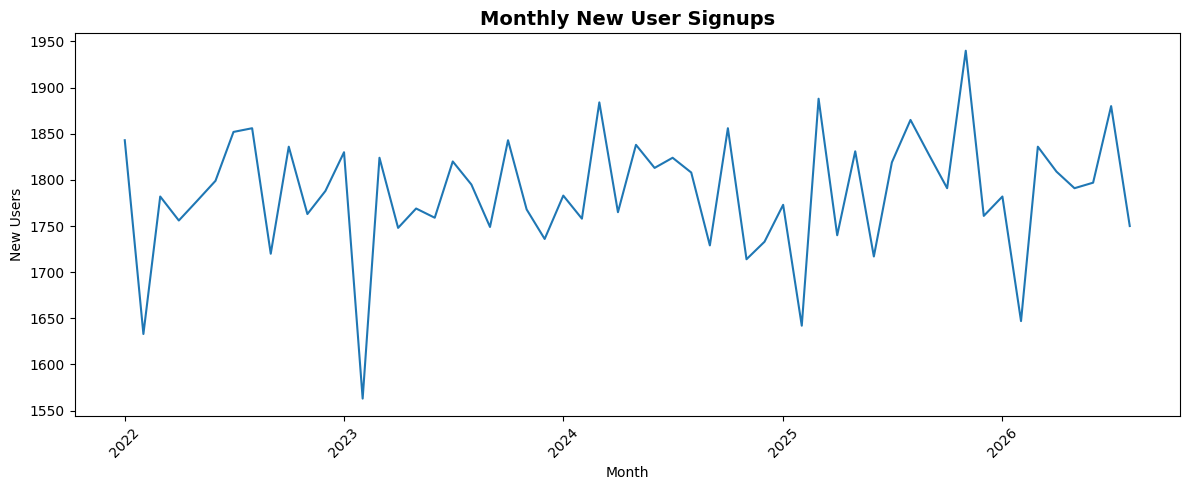

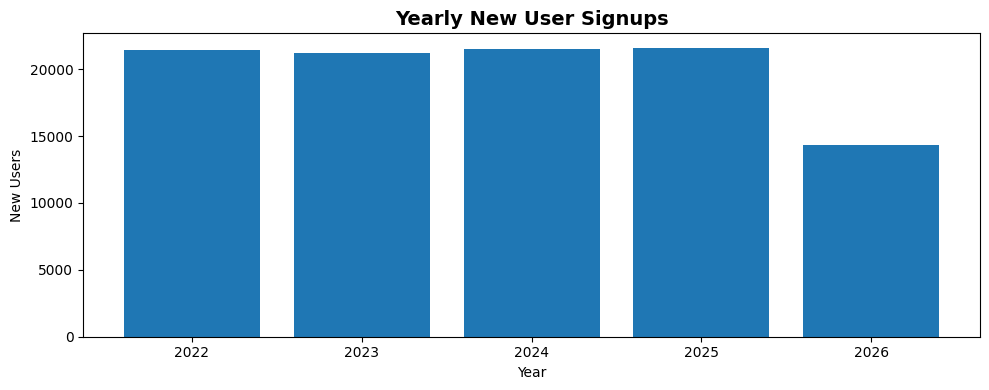

In [58]:
# 6.1 Monthly user signups
monthly_signups = (users.set_index("signup_date").resample("MS").size().reset_index(name="new_users"))

# 6.2 Month-over-Month growth:
monthly_signups["mom_growth_%"] = (monthly_signups["new_users"].pct_change().mul(100))
print('Month-over-Month Growth:')
display(monthly_signups.head(10))


# 6.3 Yearly growth:
yearly_signups = (users.assign(year=users["signup_date"].dt.year).groupby("year").size().reset_index(name="new_users"))

# 6.4 Year-over-Year growth:
yearly_signups["yoy_growth_%"] = (yearly_signups["new_users"].pct_change().mul(100))
print('Year-over-Year Growth:')
display(yearly_signups)

# Monthly signup chart:
plt.figure(figsize=(12, 5))
plt.plot(monthly_signups["signup_date"], monthly_signups["new_users"])
plt.title("Monthly New User Signups", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("New Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Yearly signup chart:
plt.figure(figsize=(10, 4))
plt.bar(yearly_signups["year"], yearly_signups["new_users"])
plt.title("Yearly New User Signups", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("New Users")
plt.tight_layout()
plt.show()

### 7. Basic Product Engagement EDA

Session Overview: 
Total Sessions: 7,512,229
Unique Users with Sessions: 100,000
Average Sessions per User: 75.12

Session Duration Distribution: 
count    7512229.00
mean          16.16
std           11.67
min            1.00
25%            8.00
50%           14.00
75%           22.00
max          120.00
Name: session_duration_minutes, dtype: float64


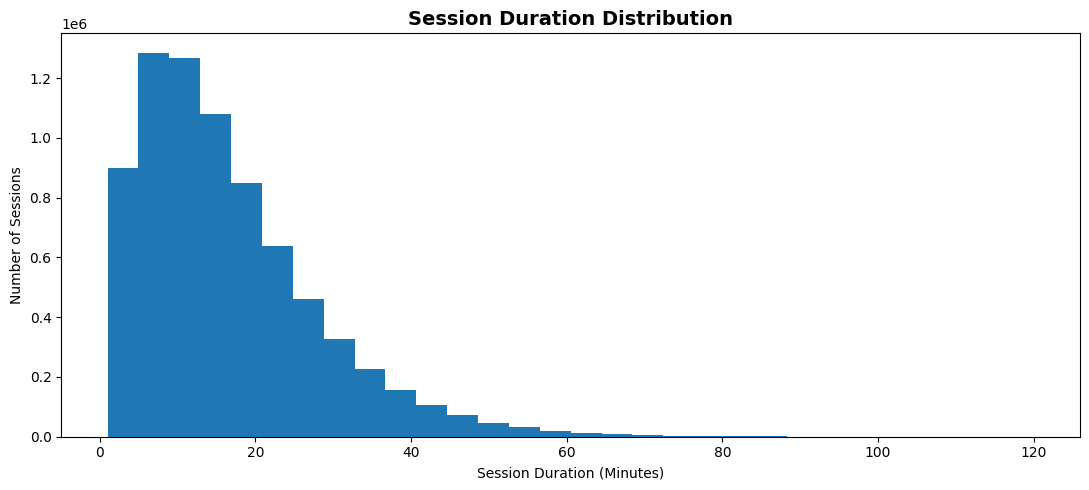

Pages Viewed per Session: 
count    7512229.00
mean           3.41
std            2.78
min            1.00
25%            1.00
50%            3.00
75%            5.00
max           40.00
Name: pages_viewed, dtype: float64


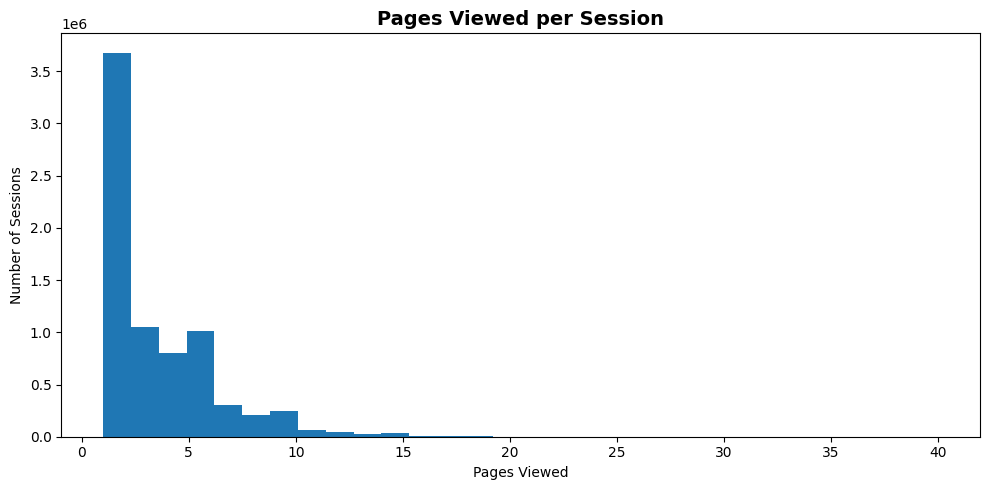

Monthly Session Trend: 


,session_date,sessions
51,2026-04-01,242483
52,2026-05-01,255576
53,2026-06-01,252615
54,2026-07-01,266577
55,2026-08-01,272212


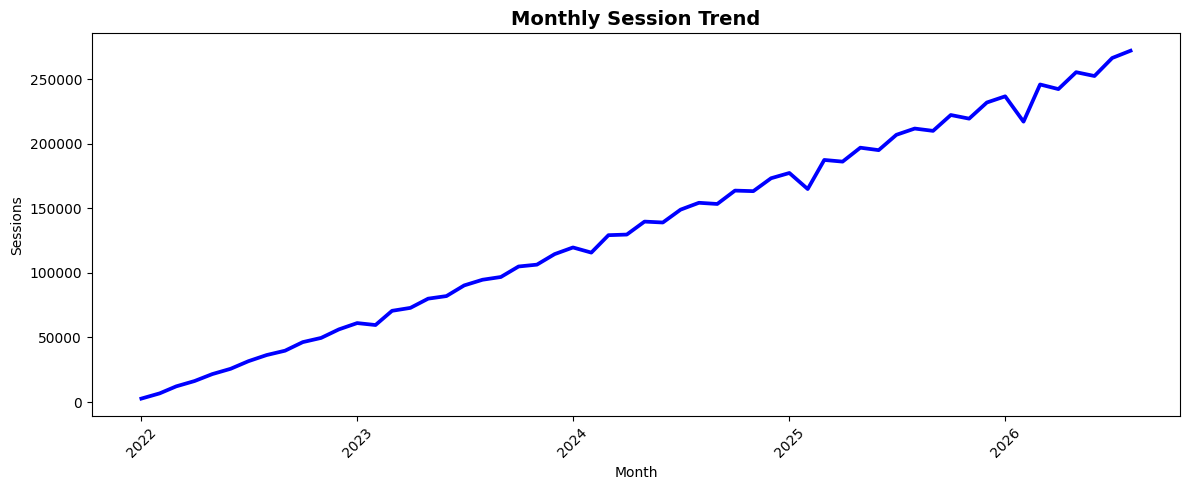

Product Event Distribution: 


,event_name,events
0,login,50937
1,dashboard_view,25449
2,search_performed,6503
3,notification_viewed,4989
4,project_created,2636
5,file_uploaded,2618
6,report_generated,2576
7,report_downloaded,1439
8,integration_connected,1437
9,team_invited,1416


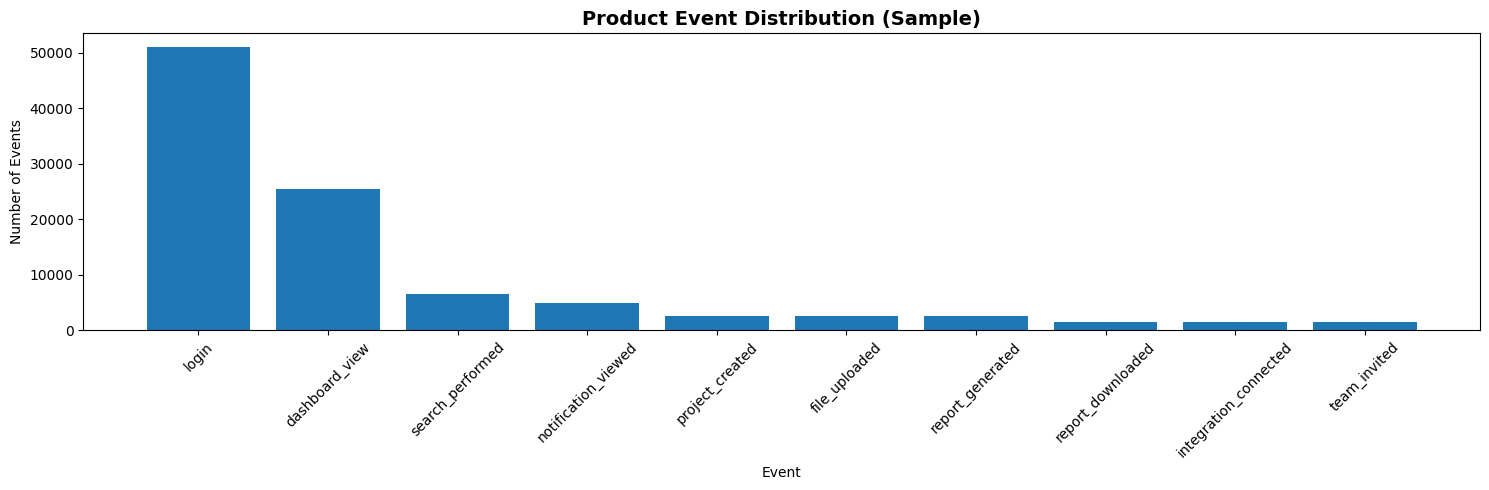

Feature Usage Overview: 


,feature_name,events
0,Authentication,50937
1,Dashboard,25449
2,Search,6503
3,Notifications,4989
4,Reporting,4015
5,Project Management,2636
6,File Management,2618
7,Integrations,1437
8,Collaboration,1416


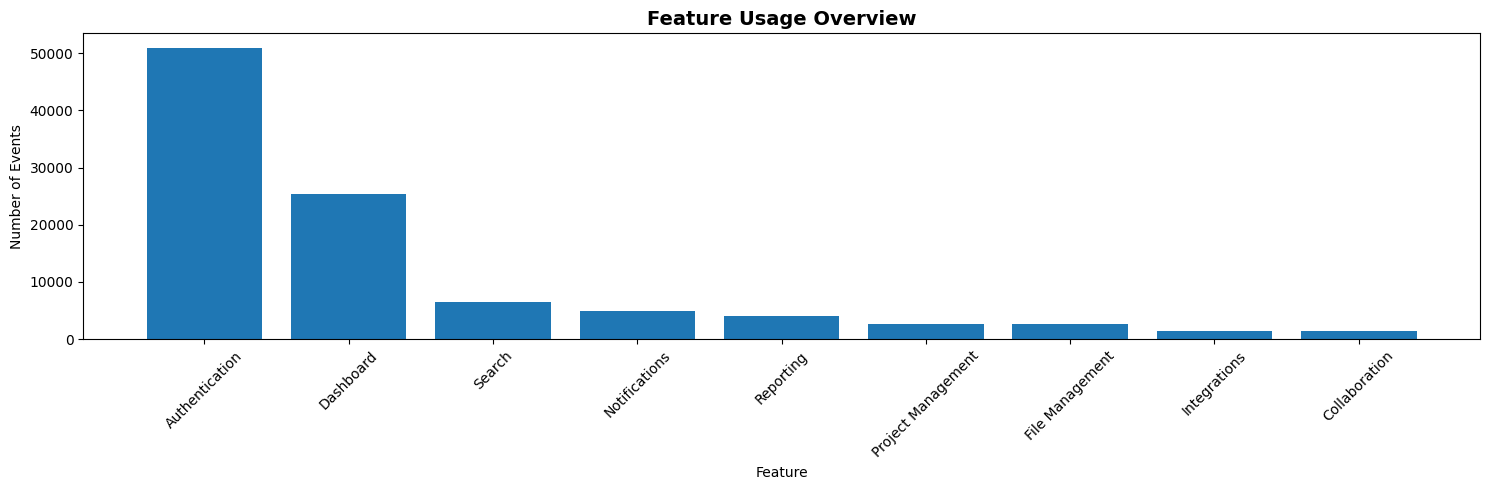

In [ ]:
# 7.1 Session Overview
print("=" * 60, "\n7.1Session Overview:", "\n" + "=" * 60)
total_sessions = len(sessions)
unique_users = sessions["user_id"].nunique()
avg_sessions_per_user = total_sessions / unique_users
print(f"Total Sessions: {total_sessions:,}")
print(f"Unique Users with Sessions: {unique_users:,}")
print(f"Average Sessions per User: {avg_sessions_per_user:.2f}")

# 7.2 Session Duration Distribution
print("\n" + "=" * 60, "\n7.2 Session Duration Distribution:", "\n" + "=" * 60)
print(sessions["session_duration_minutes"].describe().round(2))

plt.figure(figsize=(11, 5))
plt.hist(sessions["session_duration_minutes"], bins=30)
plt.title("Session Duration Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

# 7.3 Pages Viewed per Session
print("=" * 60, "\n7.3 Pages Viewed per Session:", "\n" + "=" * 60)
print(sessions["pages_viewed"].describe().round(2))

plt.figure(figsize=(10, 5))
plt.hist(sessions["pages_viewed"], bins=30)
plt.title("Pages Viewed per Session", fontsize=14, fontweight='bold')
plt.xlabel("Pages Viewed")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

# 7.4 Basic Monthly Session Trend
print("=" * 60, "\n7.4 Monthly Session Trend:", "\n" + "=" * 60)
monthly_sessions = (sessions.set_index("session_date").resample("MS").size().reset_index(name="sessions"))
display(monthly_sessions.tail(5))

plt.figure(figsize=(12, 5))
plt.plot(monthly_sessions["session_date"],monthly_sessions["sessions"], color='b', linewidth=2.7)
plt.title("Monthly Session Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7.5 Product Event Distribution
print("=" * 60, "\n7.5 Product Event Distribution:", "\n" + "=" * 60)
event_distribution = (product_events_sample['event_name'].value_counts().reset_index(name='events'))
display(event_distribution)

plt.figure(figsize=(15, 5))
plt.bar(event_distribution["event_name"], event_distribution["events"])
plt.title("Product Event Distribution (Sample)", fontsize=14, fontweight='bold')
plt.xlabel("Event")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7.6 Feature Usage Overview
print("=" * 60, "\n7.6 Feature Usage Overview:", "\n" + "=" * 60)
feature_usage = (product_events_sample["feature_name"].value_counts().reset_index(name="events"))
display(feature_usage)

plt.figure(figsize=(15, 5))
plt.bar(feature_usage["feature_name"],feature_usage["events"])
plt.title("Feature Usage Overview", fontsize=14, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8. Basic Subscription & Revenue EDA

8.1 Subscription Overview: 
Total Subscriptions: 169,981
Unique Subscribed Users: 100,000
Paid Subscriptions: 62,798
Free Subscriptions: 107,183
Average Monthly Price: $13.19

8.2 Plan Distribution: 


,plan_type,subscriptions
0,Free,107183
1,Basic,40899
2,Pro,17980
3,Enterprise,3919


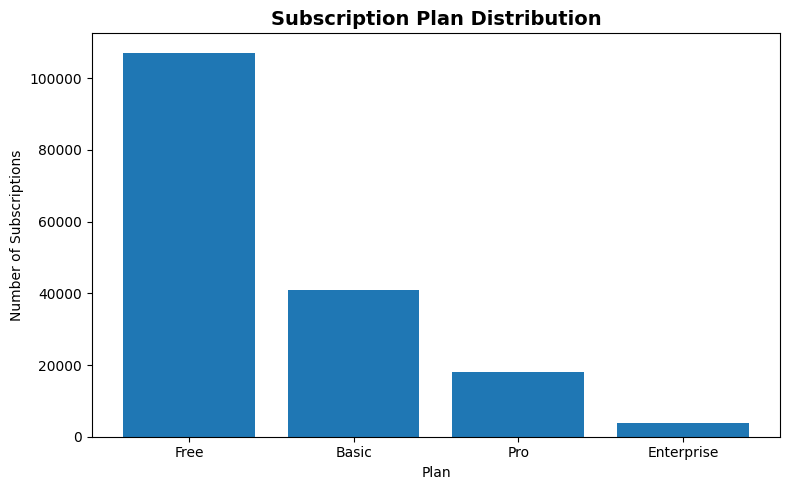

8.3 Subscription Status: 


,subscription_status,subscriptions
0,Ended,79934
1,Active,63094
2,Expired,17529
3,Cancelled,9424


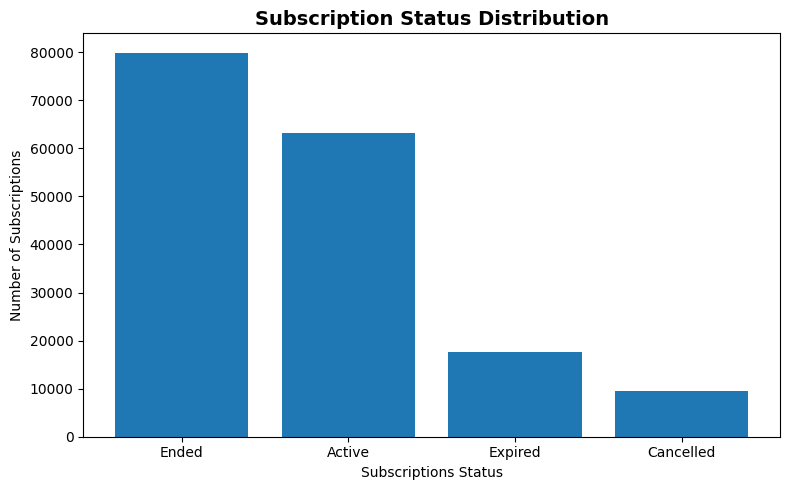

8.4 Monthly Revenue Trend: 


,transaction_date,amount
0,2022-01-01,19052.48
1,2022-02-01,36605.71
2,2022-03-01,54575.50
3,2022-04-01,72315.15
4,2022-05-01,91081.32


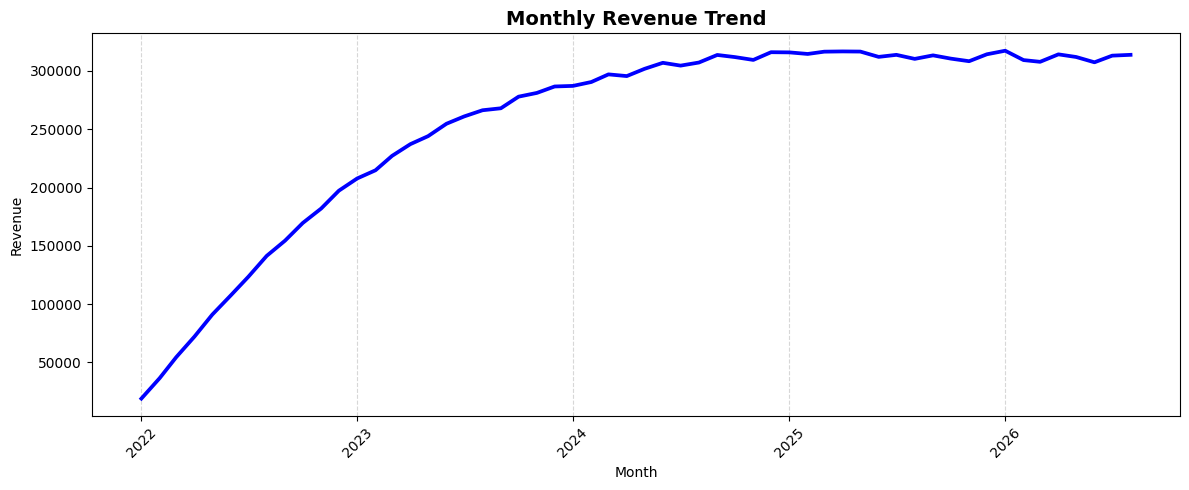

8.5 Revenue by Plan: 


,plan_type,amount
2,Pro,5621953.38
0,Basic,4934219.51
1,Enterprise,3718470.14


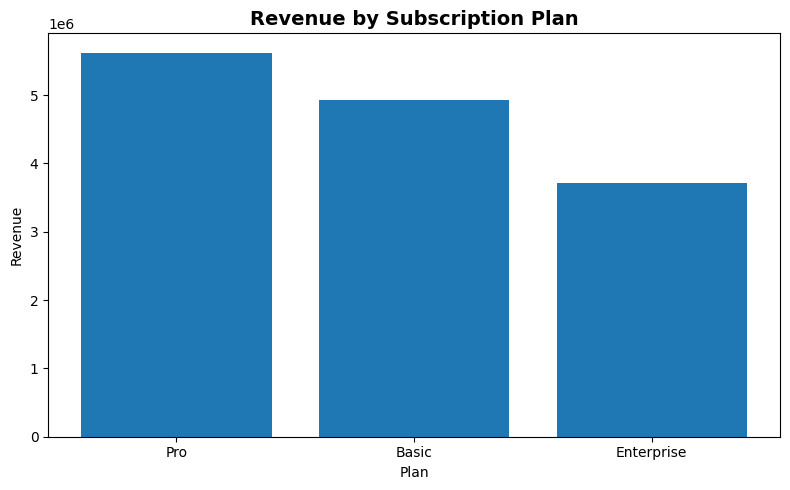

In [ ]:
# 8.1 Subscription Overview
print("=" * 60, "\n8.1 Subscription Overview:", "\n" + "=" * 60)
unique_subscribed_users = subscriptions["user_id"].nunique()
paid_subscriptions = (subscriptions["monthly_price"] > 0).sum()
free_subscriptions = (subscriptions["monthly_price"] == 0).sum()
average_monthly_prices = subscriptions["monthly_price"].mean()

print(f"Total Subscriptions: {len(subscriptions):,}")
print(f"Unique Subscribed Users: {unique_subscribed_users:,}")
print(f"Paid Subscriptions: {paid_subscriptions:,}")
print(f"Free Subscriptions: {free_subscriptions:,}")
print(f"Average Monthly Price: ${average_monthly_prices:,.2f}")

# 8.2 Plan Distribution
print("\n" + "=" * 60, "\n8.2 Plan Distribution:", "\n" + "=" * 60)
plan_distribution = ( subscriptions["plan_type"].value_counts().reset_index(name="subscriptions"))
display(plan_distribution)

plt.figure(figsize=(8, 5))
plt.bar(plan_distribution["plan_type"],plan_distribution["subscriptions"])
plt.title("Subscription Plan Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Plan")
plt.ylabel("Number of Subscriptions")
plt.tight_layout()
plt.show()

# 8.3 Subscription Status
print("=" * 60, "\n8.3 Subscription Status:", "\n" + "=" * 60)
status_distribution = (subscriptions["subscription_status"].value_counts().reset_index(name="subscriptions"))
display(status_distribution)

plt.figure(figsize=(8, 5))
plt.bar(status_distribution["subscription_status"], status_distribution["subscriptions"])
plt.title("Subscription Status Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Subscriptions Status")
plt.ylabel("Number of Subscriptions")
plt.tight_layout()
plt.show()

# 8.4 Monthly Revenue Trend
print("=" * 60, "\n8.4 Monthly Revenue Trend:", "\n" + "=" * 60)
successful_transactions = transactions[transactions["transaction_status"] == "Successful"].copy()

monthly_revenue = (successful_transactions.set_index("transaction_date").resample("MS")["amount"].sum().reset_index())
display(monthly_revenue.head())

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["transaction_date"], monthly_revenue["amount"], color='b', linewidth=2.7)
plt.title("Monthly Revenue Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5,axis='x')
plt.show()

# 8.5 Revenue by Plan
print("=" * 60, "\n8.5 Revenue by Plan:", "\n" + "=" * 60)
revenue_by_plan = (
    successful_transactions.merge(subscriptions[["subscription_id", "plan_type"]], on="subscription_id", how="left")
    .groupby("plan_type")["amount"].sum().reset_index().sort_values("amount", ascending=False)
)
display(revenue_by_plan)

plt.figure(figsize=(8, 4))
plt.bar(revenue_by_plan["plan_type"],revenue_by_plan["amount"])
plt.title("Revenue by Subscription Plan", fontsize=14, fontweight='bold')
plt.xlabel("Plan")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### 9. Basic Marketing & Support EDA

9.1 Marketing Overview: 
Marketing Records: 100,000
Unique Users: 100,000
Total Impressions: 852,015,444
Total Clicks: 45,668,202
Total Conversions: 4,128,641
Total Spend: $34,261,614.56

9.2 Marketing Channel Distribution: 


,channel,records
0,Organic Search,25107
1,Google Ads,20114
2,Facebook Ads,14926
3,Instagram,11926
4,Email,9996
5,Referral,9955
6,LinkedIn,7976


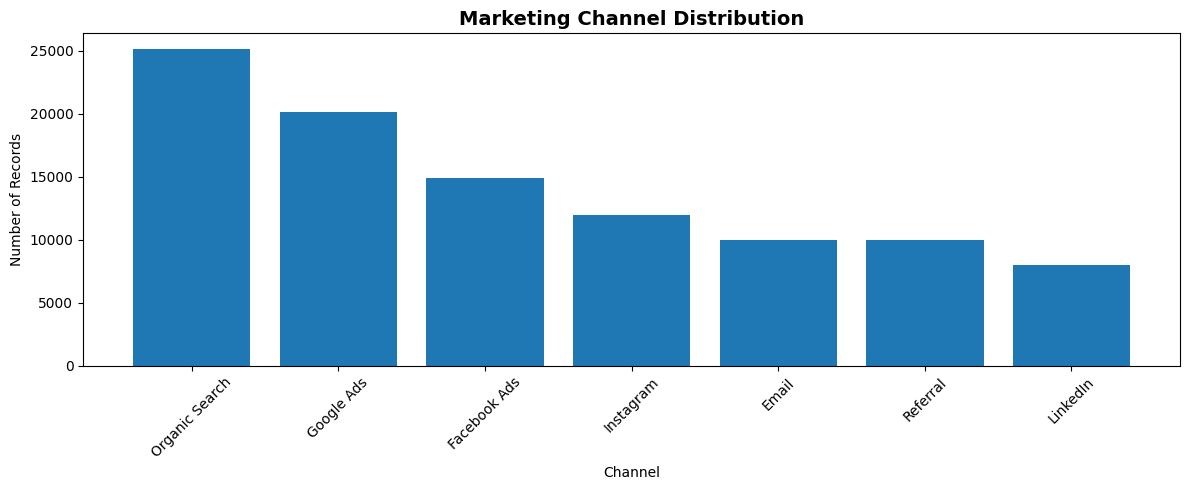

9.3 Campaign Performance: 


,channel,impressions,clicks,conversions,spend,ctr_%,conversion_rate_%
0,Email,25704625,4210107,585119,165615.55,16.378792,13.897960
1,Facebook Ads,152280226,4550449,209460,3391012.88,2.988207,4.603062
2,Google Ads,206491767,11386919,785527,18763077.88,5.514466,6.898503
3,Instagram,121332195,3334301,152403,2090531.51,2.748076,4.570763
4,LinkedIn,82024071,2666948,261876,7341501.54,3.251421,9.819314
5,Organic Search,256475001,17981170,1869828,2233321.66,7.010886,10.398812
6,Referral,7707559,1538308,264428,276553.54,19.958433,17.189536


9.4 Support Ticket Overview: 
Total Tickets: 35,673
Unique Users: 28,013
Average Resolution Time: 22.47 hours

9.5 Ticket Category Distribution: 


,category,tickets
0,Technical Issue,9981
1,Login / Access,6484
2,Billing,5289
3,Performance,4182
4,Feature Request,3599
5,Account Issue,3261
6,Integration,2877


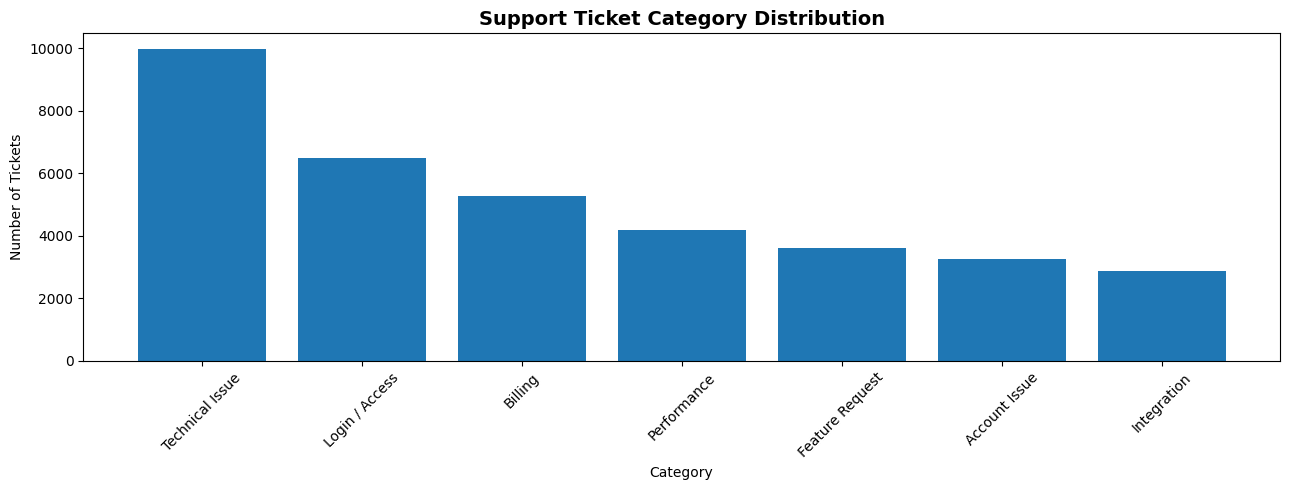

9.6 Resolution Time Distribution: 


count    35673.00
mean        22.47
std         19.67
min          0.50
25%          8.95
50%         16.77
75%         29.58
max        168.00
Name: resolution_time_hours, dtype: float64

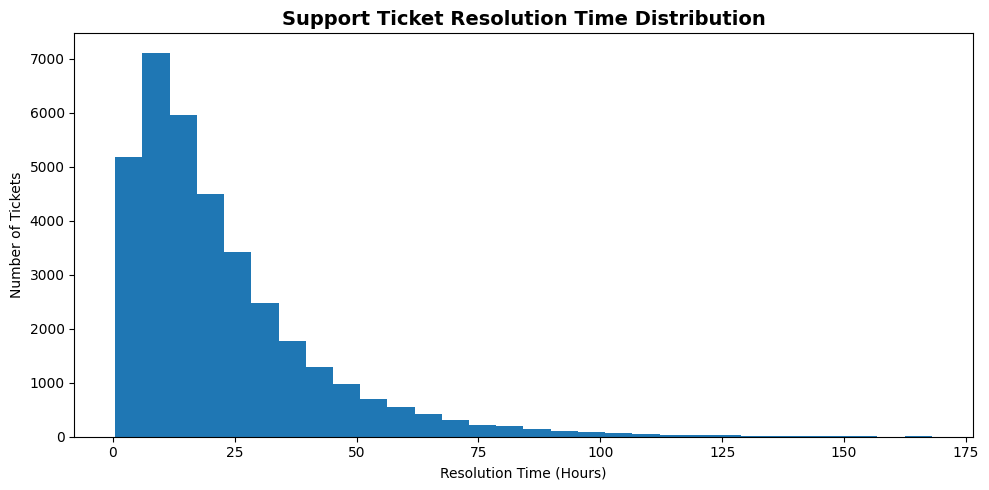

In [ ]:
# 9.1 Marketing Overview
print("=" * 60, "\n9.1 Marketing Overview:", "\n" + "=" * 60)
unique_marketing_users = marketing["user_id"].nunique()
total_impressions = marketing["impressions"].sum()
total_clicks = marketing["clicks"].sum()
total_conversions = marketing["conversion"].sum()
total_spend = marketing["spend"].sum()

print(f"Marketing Records: {len(marketing):,}")
print(f"Unique Users: {unique_marketing_users:,}")
print(f"Total Impressions: {total_impressions:,}")
print(f"Total Clicks: {total_clicks:,}")
print(f"Total Conversions: {total_conversions:,}")
print(f"Total Spend: ${total_spend:,.2f}")

# 9.2 Marketing Channel Distribution
print("\n" + "=" * 60, "\n9.2 Marketing Channel Distribution:", "\n" + "=" * 60)
channel_distribution = (marketing["channel"].value_counts().reset_index(name="records"))
display(channel_distribution)

plt.figure(figsize=(12, 5))
plt.bar(channel_distribution["channel"], channel_distribution["records"])
plt.title("Marketing Channel Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Channel")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9.3 Basic Campaign Performance
print("=" * 60, "\n9.3 Campaign Performance:", "\n" + "=" * 60)
campaign_performance = (
    marketing
    .groupby("channel")
    .agg(
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        conversions=("conversion", "sum"),
        spend=("spend", "sum")
    )
    .reset_index()
)
campaign_performance["ctr_%"] = (campaign_performance["clicks"] / campaign_performance["impressions"]* 100)
campaign_performance["conversion_rate_%"] = (campaign_performance["conversions"] / campaign_performance["clicks"]* 100)
display(campaign_performance)


# 9.4 Support Ticket Overview
print("\n" + "=" * 60, "\n9.4 Support Ticket Overview:", "\n" + "=" * 60)
total_tickets = len(support)
unique_ticket_users = support["user_id"].nunique()
average_resolution = support["resolution_time_hours"].mean()

print(f"Total Tickets: {total_tickets:,}")
print(f"Unique Users: {unique_ticket_users:,}")
print(f"Average Resolution Time: {average_resolution:.2f} hours")


# 9.5 Ticket Category Distribution
print("\n" + "=" * 60, "\n9.5 Ticket Category Distribution:", "\n" + "=" * 60)
ticket_categories = (support["category"].value_counts().reset_index(name="tickets"))
display(ticket_categories)

plt.figure(figsize=(13, 5))
plt.bar(ticket_categories["category"],ticket_categories["tickets"])
plt.title("Support Ticket Category Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 9.6 Resolution Time Distribution
print("=" * 60, "\n9.6 Resolution Time Distribution:", "\n" + "=" * 60)
display(support["resolution_time_hours"].describe().round(2))

plt.figure(figsize=(10, 5))
plt.hist(support["resolution_time_hours"], bins=30)

plt.title("Support Ticket Resolution Time Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

### 10. Initial Observations

- The dataset covers the period from January 2022 to August 2026 and contains 100,000 users.

- The platform recorded 7,512,229 user sessions, with an average of 75.12 sessions per user across the available period.

- The product event dataset contains 14,713,576 events linked to the recorded sessions, providing a large-scale view of user-product interactions.

- The subscription dataset contains 169,981 subscription records, indicating that some users have multiple subscription periods.

- The transaction dataset contains 445,665 payment transactions with a total transaction value of approximately $15.55 million.

- Marketing data contains 100,000 user-level acquisition records covering multiple acquisition channels.

- The support dataset contains 35,673 tickets from 28,013 unique users, with an average resolution time of approximately 22.47 hours.

- These datasets provide a foundation for further analysis of user growth, product engagement, conversion, revenue, retention, and churn using SQL and Power BI.